# Распознание пользовательских именованных объектов

## Работа в аудитории

### Грамматические теги

Грамматические теги (далее - теги POS) – это аннотирование слова в заданном тексте в соответствии с его соответствующей частью речи.
Для простоты будем считать, что каждое слово относится к одной из четырех POS-категорий: существительное, прилагательное, наречие и глагол.
Однако с лингвистической точки зрения существует много других ролей, помимо этих четырех.

Существует несколько вариантов тегов POS, среди которых наиболее известным является [Penn Treebank POS](https://www.sketchengine.eu/penn-treebank-tagset/). Ниже показано их краткое изложение и соответствующее описание:


|POS Tag|Description|Example|
|---|---|---|
|CC|coordinating conjunction|and|
|CD|cardinal number|1, third|
|DT|determiner|the|
|EX|existential there|there is|
|FW|foreign word|les|
|IN|preposition, subordinating conjunction|in, of, like|
|IN/that|that as subordinator|that|
|JJ|adjective|green|
|JJR|adjective, comparative|greener|
|JJS|adjective, superlative|greenest|
|LS|list marker|1)|
|MD|modal|could, will|
|NN|noun, singular or mass|table|
|NNS|noun plural|tables|
|NP|proper noun, singular|John|
|NPS|proper noun, plural|Vikings|
|PDT|predeterminer|both the boys|
|POS|possessive ending|friend’s|
|PP|personal pronoun|I, he, it|
|PPZ|possessive pronoun|my, his|
|RB|adverb|however, usually, naturally, here, good|
|RBR|adverb, comparative|better|
|RBS|adverb, superlative|best|
|RP|particle|give up|
|SENT|Sentence-break punctuation|. ! ?|
|SYM|Symbol|/ [ = *|
|TO|infinitive ‘to’|togo|
|UH|interjection|uhhuhhuhh|
|VB|verb be, base form|be|
|VBD|verb be, past tense|was, were|
|VBG|verb be, gerund/present participle|being|
|VBN|verb be, past participle|been|
|VBP|verb be, sing. present, non-3d|am, are|
|VBZ|verb be, 3rd person sing. present|is|
|VH|verb have, base form|have|
|VHD|verb have, past tense|had|
|VHG|verb have, gerund/present participle|having|
|VHN|verb have, past participle|had|
|VHP|verb have, sing. present, non-3d|have|
|VHZ|verb have, 3rd person sing. present|has|
|VV|verb, base form|take|
|VVD|verb, past tense|took|
|VVG|verb, gerund/present participle|taking|
|VVN|verb, past participle|taken|
|VVP|verb, sing. present, non-3d|take|
|VVZ|verb, 3rd person sing. present|takes|
|WDT|wh-determiner|which|
|WP|wh-pronoun|who, what|
|WP\$|possessive wh-pronoun|whose|
|WRB|wh-abverb|where, when|
|\#|\#|\#|
|\$|\$|\$|
|“|Quotation marks|‘ “|
|``|Opening quotation marks|‘ “|
|(|Opening brackets|( \{|
|)|Closing brackets|) \}|
|,|Comma|,|
|:|Punctuation|– ; : — …|


Аннотации этих тегов очень полезны в определенных приложениях NLP и являются одним из строительных блоков многих других методов. Трансформеры способны таким образом понимать взаимосвязь слов благодаря своей сложной архитектуре.

Много моделей уже было предобучено на тексте, содержащем теги POS.
Это позволяет таким моделям лучше справляться с распознаванием общеизвестных именованных объектов (Named-entity recognition, NER).
Ниже рассмотрен пример для анлгийского языка для распознавания.

Загрузим модель по умолчнанию и в переменной `nlp` создадим объект:

In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import pipeline
nlp = pipeline('ner', 'dslim/bert-base-NER')

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
example = "An apple was eaten by Sofia when she called her teacher on the apple phone."
nlp(example)

[{'entity': 'B-PER',
  'score': np.float32(0.70918),
  'index': 6,
  'word': 'Sofia',
  'start': 22,
  'end': 27}]

Запишем в переменную `example` пример текста и передадим объекту `nlp` для распознавания:

In [ ]:
example = "My name is Alexander. I was born in Moscow and now live in Saint Petersburg."
nlp(example)

[{'entity': 'I-PER',
  'score': np.float32(0.9987822),
  'index': 4,
  'word': 'Alexander',
  'start': 11,
  'end': 20},
 {'entity': 'I-LOC',
  'score': np.float32(0.99921536),
  'index': 10,
  'word': 'Moscow',
  'start': 36,
  'end': 42},
 {'entity': 'I-LOC',
  'score': np.float32(0.99965477),
  'index': 15,
  'word': 'Saint',
  'start': 59,
  'end': 64},
 {'entity': 'I-LOC',
  'score': np.float32(0.9997173),
  'index': 16,
  'word': 'Petersburg',
  'start': 65,
  'end': 75}]

In [ ]:
example = "My name is Alexander. I was born in Moscow and now live in Saint Petersburg. Now I work at Элетек"
nlp(example)

[{'entity': 'I-PER',
  'score': np.float32(0.99860305),
  'index': 4,
  'word': 'Alexander',
  'start': 11,
  'end': 20},
 {'entity': 'I-LOC',
  'score': np.float32(0.99914706),
  'index': 10,
  'word': 'Moscow',
  'start': 36,
  'end': 42},
 {'entity': 'I-LOC',
  'score': np.float32(0.9996468),
  'index': 15,
  'word': 'Saint',
  'start': 59,
  'end': 64},
 {'entity': 'I-LOC',
  'score': np.float32(0.9997011),
  'index': 16,
  'word': 'Petersburg',
  'start': 65,
  'end': 75},
 {'entity': 'I-ORG',
  'score': np.float32(0.98028046),
  'index': 22,
  'word': 'Э',
  'start': 91,
  'end': 92},
 {'entity': 'I-ORG',
  'score': np.float32(0.96609837),
  'index': 23,
  'word': '##л',
  'start': 92,
  'end': 93},
 {'entity': 'I-ORG',
  'score': np.float32(0.94548357),
  'index': 24,
  'word': '##е',
  'start': 93,
  'end': 94},
 {'entity': 'I-ORG',
  'score': np.float32(0.9680971),
  'index': 25,
  'word': '##т',
  'start': 94,
  'end': 95},
 {'entity': 'I-ORG',
  'score': np.float32(0.8388276

Из вывода видно, что были распознаны и возвращены сведения об имени и локациях.
Следует заметить, что в этом примере составная локация рассматривается как две сущности.

### Дообучение языковых моделей для распознавания пользовательских именованных объектов

Одной из хорошо известных задач в категории классификации токенов является NER – распознавание того, является токен объектом или нет, и определение типа каждого обнаруженного объекта. Например, текст может одновременно содержать несколько объектов – имена людей, местоположения, организации и другие типы. Следующий текст является ярким примером NER:

*Джордж Вашингтон – один из президентов Соединенных Штатов Америки.*

*Джордж Вашингтон* – это имя человека, а *Соединенные Штаты Америки* – это название места. Ожидается, что модель маркировки последовательности по- метит все слова тегами, каждый из которых содержит информацию о теге. Для стандартных задач NER повсеместно используются теги BIO. В следующей таблице представлен список тегов и их описание.

|Тег|Описание|
|---|---|
|O| Outside of entity / За пределами объекта|
|B-PER| Beginning of Person entity / Начало объекта «Персона»|
|I-PER | Inside of Person entity / Внутри объекта «Персона»|
|B-LOC| Beginning of Location entity / Начало объекта «Местоположение»|
|I-LOC| Inside of Location entity / Внутри объекта «Местоположение»|
|B-ORG| Beginning of Organization entity / Начало объекта «Организация»|
|I-ORG| Inside of Organization entity / Внутри объекта «Организация»|
|B-MISC| Beginning of Miscellaneous entity / Начало объекта «Прочее»|
|I-MISC| Inside of Miscellaneous entity / Внутри объекта «Прочее»|

В этой таблице `B` обозначает начало тега, `I` обозначает внутреннюю часть тега, а `O` – внешнюю часть объекта (т.е. не относящееся к искомым тегам). Из этих трех букв составлено название ан- нотации BIO. Например, так будет выглядеть приведенное выше предложение, если его аннотировать с помощью BIO:
```
[B-PER|Джордж] [I-PER|Вашингтон] [O|один] [O|из] [O|президентов] [B-LOC|Соединенных] [I-LOC|Штатов]
[I-LOC|Америки] [O|.]
```
Соответственно, входная последовательность должна быть размечена в формате BIO.
В дополнение к тегам NER в этом наборе данных до-
ступны также теги POS.


In [ ]:
!pip install -qU transformers[torch] datasets evaluate seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:

In [ ]:
import datasets
conll2003 = datasets.load_dataset("conll2003")

README.md:   0%|          | 0.00/12.3k [00:00<?, ?B/s]

conll2003.py:   0%|          | 0.00/9.57k [00:00<?, ?B/s]

The repository for conll2003 contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/conll2003.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

In [ ]:
conll2003["train"].features['ner_tags']

Sequence(feature=ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC'], id=None), length=-1, id=None)

In [ ]:
conll2003["train"][0]

{'id': '0',
 'tokens': ['EU',
  'rejects',
  'German',
  'call',
  'to',
  'boycott',
  'British',
  'lamb',
  '.'],
 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7],
 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0],
 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0]}

In [ ]:
conll2003["train"].features["ner_tags"]

Sequence(feature=ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC'], id=None), length=-1, id=None)

In [ ]:
from transformers import BertTokenizerFast
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

In [ ]:
def tokenize_and_align_labels(examples, label_all_tokens=True):
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)
    labels = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                 label_ids.append(label[word_idx])
            else:
                 label_ids.append(label[word_idx] if label_all_tokens else -100)
            previous_word_idx = word_idx
        labels.append(label_ids)
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

In [ ]:
q = tokenize_and_align_labels(conll2003['train'][4:5])
q

{'input_ids': [[101, 2762, 1005, 1055, 4387, 2000, 1996, 2647, 2586, 1005, 1055, 15651, 2837, 14121, 1062, 9328, 5804, 2056, 2006, 9317, 10390, 2323, 4965, 8351, 4168, 4017, 2013, 3032, 2060, 2084, 3725, 2127, 1996, 4045, 6040, 2001, 24509, 1012, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], 'labels': [[-100, 5, 0, 0, 0, 0, 0, 3, 4, 0, 0, 0, 0, 1, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, -100]]}

In [ ]:
for token, label in zip(tokenizer.convert_ids_to_tokens(q["input_ids"][0]),q["labels"][0]):
    print(f"{token:_<40} {label}")

[CLS]___________________________________ -100
germany_________________________________ 5
'_______________________________________ 0
s_______________________________________ 0
representative__________________________ 0
to______________________________________ 0
the_____________________________________ 0
european________________________________ 3
union___________________________________ 4
'_______________________________________ 0
s_______________________________________ 0
veterinary______________________________ 0
committee_______________________________ 0
werner__________________________________ 1
z_______________________________________ 2
##wing__________________________________ 2
##mann__________________________________ 2
said____________________________________ 0
on______________________________________ 0
wednesday_______________________________ 0
consumers_______________________________ 0
should__________________________________ 0
buy_____________________________________ 0
sheep___

In [ ]:
tokenized_datasets = conll2003.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForTokenClassification
model = AutoModelForTokenClassification.from_pretrained("bert-base-uncased", num_labels=9)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainingArguments, Trainer
args = TrainingArguments(
    "CustomNER",
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to="none"
)

In [ ]:
from transformers import DataCollatorForTokenClassification
data_collator = DataCollatorForTokenClassification(tokenizer)

In [ ]:
from evaluate import load
metric = load("seqeval")

In [ ]:
example = conll2003['train'][0]

In [ ]:
label_list = conll2003["train"].features["ner_tags"].feature.names

labels = [label_list[i] for i in example["ner_tags"]]

metric.compute(predictions=[labels], references=[labels])

{'MISC': {'precision': np.float64(1.0),
  'recall': np.float64(1.0),
  'f1': np.float64(1.0),
  'number': np.int64(2)},
 'ORG': {'precision': np.float64(1.0),
  'recall': np.float64(1.0),
  'f1': np.float64(1.0),
  'number': np.int64(1)},
 'overall_precision': np.float64(1.0),
 'overall_recall': np.float64(1.0),
 'overall_f1': np.float64(1.0),
 'overall_accuracy': 1.0}

In [ ]:
import numpy as np
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
      [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
       for prediction, label in zip(predictions, labels)
   ]
    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
   "precision": results["overall_precision"],
   "recall": results["overall_recall"],
   "f1": results["overall_f1"],
  "accuracy": results["overall_accuracy"],
  }

In [ ]:
trainer = Trainer(
    model,
    args,
   train_dataset=tokenized_datasets["train"],
   eval_dataset=tokenized_datasets["validation"],
   data_collator=data_collator,
   tokenizer=tokenizer,
   compute_metrics=compute_metrics,
)

<ipython-input-88-b3133c62b26c>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.065670,0.930542,0.939702,0.935100,0.984908
2,No log,0.064367,0.930186,0.943506,0.936799,0.985019
3,0.015200,0.065352,0.931168,0.942835,0.936965,0.985146


TrainOutput(global_step=660, training_loss=0.014795668919881185, metrics={'train_runtime': 553.4185, 'train_samples_per_second': 76.114, 'train_steps_per_second': 1.193, 'total_flos': 1232723514965742.0, 'train_loss': 0.014795668919881185, 'epoch': 3.0})

In [ ]:
PATH = 'BestCustomNER'
model.save_pretrained(PATH)
tokenizer.save_pretrained(PATH)

('BestCustomNER/tokenizer_config.json',
 'BestCustomNER/special_tokens_map.json',
 'BestCustomNER/vocab.txt',
 'BestCustomNER/added_tokens.json',
 'BestCustomNER/tokenizer.json')

In [ ]:
id2label = {
    str(i): label for i,label in enumerate(label_list)
}
label2id = {
    label: str(i) for i,label in enumerate(label_list)
}

In [ ]:
import json
config = json.load(open(f"{PATH}/config.json"))

In [ ]:
config["id2label"] = id2label
config["label2id"] = label2id

In [ ]:
json.dump(config, open(f"{PATH}/config.json","w"))

In [ ]:
mmodel = AutoModelForTokenClassification.from_pretrained(PATH)

In [ ]:
from transformers import pipeline
nlp = pipeline("ner", model=mmodel, tokenizer=tokenizer)

Device set to use cuda:0


In [ ]:
example = "I live in Moscow"
ner_results = nlp(example)
print(ner_results)

[{'entity': 'B-LOC', 'score': np.float32(0.9986405), 'index': 4, 'word': 'moscow', 'start': 10, 'end': 16}]


## Самостоятельная работа

**Задание.** Обучите модель NER, которая получит на тестовой части качество по метрике F1 более 0.9.

In [1]:
!pip install -qU transformers[torch] "datasets<4.0.0" accelerate evaluate seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.7 MB/s eta 0:00:00


In [2]:
from datasets import load_dataset

wnut = load_dataset("wnut_17")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wnut_17.py: 0.00B [00:00, ?B/s]

The repository for wnut_17 contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/wnut_17.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating train split:   0%|          | 0/3394 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1009 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1287 [00:00<?, ? examples/s]

In [3]:
wnut["train"].features["ner_tags"]

Sequence(feature=ClassLabel(names=['O', 'B-corporation', 'I-corporation', 'B-creative-work', 'I-creative-work', 'B-group', 'I-group', 'B-location', 'I-location', 'B-person', 'I-person', 'B-product', 'I-product'], id=None), length=-1, id=None)

In [4]:
wnut["train"][0]

{'id': '0',
 'tokens': ['@paulwalk',
  'It',
  "'s",
  'the',
  'view',
  'from',
  'where',
  'I',
  "'m",
  'living',
  'for',
  'two',
  'weeks',
  '.',
  'Empire',
  'State',
  'Building',
  '=',
  'ESB',
  '.',
  'Pretty',
  'bad',
  'storm',
  'here',
  'last',
  'evening',
  '.'],
 'ner_tags': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  7,
  8,
  8,
  0,
  7,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0]}

In [5]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("roberta-large", use_fast=True, add_prefix_space=True)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [6]:
label_list = wnut["train"].features["ner_tags"].feature.names

In [7]:
def tokenize_and_align_labels(examples, label_all_tokens=True):
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)
    labels = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                if not label_all_tokens:
                    label_ids.append(-100)
                else:
                    lab = label[word_idx]
                    if lab != 0:
                        tag_name = label_list[lab]
                        if tag_name.startswith("B-"):
                            i_name = "I-" + tag_name[2:]
                            lab = label_list.index(i_name)
                    label_ids.append(lab)
            previous_word_idx = word_idx
        labels.append(label_ids)
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

In [8]:
tokenized_datasets = wnut.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/3394 [00:00<?, ? examples/s]

Map:   0%|          | 0/1009 [00:00<?, ? examples/s]

Map:   0%|          | 0/1287 [00:00<?, ? examples/s]

In [9]:
from transformers import AutoModelForTokenClassification
model = AutoModelForTokenClassification.from_pretrained("roberta-large", num_labels=len(label_list))

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaForTokenClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
from transformers import TrainingArguments, Trainer
args = TrainingArguments(
    "CustomNER_WNUT17",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to="none",
    logging_steps=10
)

In [11]:
from transformers import DataCollatorForTokenClassification
data_collator = DataCollatorForTokenClassification(tokenizer)

In [12]:
from evaluate import load
metric = load("seqeval")

In [13]:
import numpy as np

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
      [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
       for prediction, label in zip(predictions, labels)
   ]
    results = metric.compute(predictions=true_predictions, references=true_labels)

    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

In [14]:
trainer = Trainer(
    model,
    args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

/tmp/ipython-input-3199735963.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [15]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.127500,0.242679,0.604506,0.577751,0.590826,0.944032
2,0.082100,0.264328,0.660511,0.556220,0.603896,0.944032
3,0.046800,0.277321,0.722701,0.601675,0.656658,0.949212
4,0.045600,0.289851,0.696570,0.631579,0.662484,0.952083
5,0.018500,0.322317,0.692722,0.614833,0.651458,0.950732


TrainOutput(global_step=1065, training_loss=0.07423412806831055, metrics={'train_runtime': 832.1219, 'train_samples_per_second': 20.394, 'train_steps_per_second': 1.28, 'total_flos': 1584222800925864.0, 'train_loss': 0.07423412806831055, 'epoch': 5.0})

In [16]:
PATH = 'BestCustomNER_WNUT17'
model.save_pretrained(PATH)
tokenizer.save_pretrained(PATH)

('BestCustomNER_WNUT17/tokenizer_config.json',
 'BestCustomNER_WNUT17/special_tokens_map.json',
 'BestCustomNER_WNUT17/vocab.json',
 'BestCustomNER_WNUT17/merges.txt',
 'BestCustomNER_WNUT17/added_tokens.json',
 'BestCustomNER_WNUT17/tokenizer.json')

In [17]:
id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in enumerate(label_list)}

In [18]:
import json
config = json.load(open(f"{PATH}/config.json"))

In [19]:
config["id2label"] = {str(k): v for k, v in id2label.items()}
config["label2id"] = {k: int(v) for k, v in label2id.items()}

In [20]:
json.dump(config, open(f"{PATH}/config.json","w"))

In [21]:
model = AutoModelForTokenClassification.from_pretrained(PATH)

In [22]:
from transformers import pipeline
nlp = pipeline("ner", model=model, tokenizer=tokenizer, aggregation_strategy="simple")

Device set to use cuda:0


In [23]:
example = "My name is Alexander. I was born in Moscow and now live in Saint Petersburg."
nlp(example)

[{'entity_group': 'person',
  'score': np.float32(0.962548),
  'word': ' Alexander',
  'start': 11,
  'end': 20},
 {'entity_group': 'location',
  'score': np.float32(0.87911105),
  'word': ' Moscow',
  'start': 36,
  'end': 42},
 {'entity_group': 'location',
  'score': np.float32(0.93775797),
  'word': ' Saint Petersburg',
  'start': 59,
  'end': 75}]

Нашел статью с обзором датасета - https://aclanthology.org/W17-4418.pdf

По ней видно, что он не особо сбалансирован - этим фактом можно объяснить падение ошибки на тесте и рост на валидации, а также результат $F1 \approx 66%$

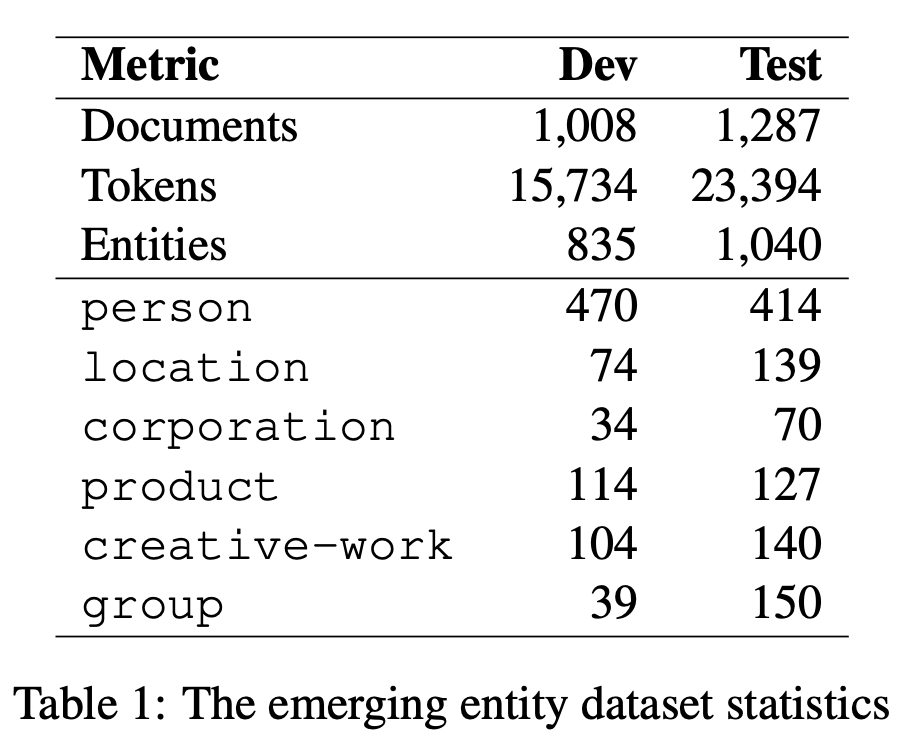